# Assignment 2: Evaluating and Extending an RNN based Part-of-Speech Tagger


In [2]:
# Our standard imports for maths and basic methodology
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

import os
import random
import urllib.request
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
if torch.cuda.is_available():
  for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))
else:
  print("No GPU available")

No GPU available


Conllu format

In [ ]:
def parse_conllu(filepath, use_upos=True):
    """
    Parse a CoNLL-U file into a list of (word_list, tag_list) sentence pairs.
    Columns: 0=ID | 1=FORM | 2=LEMMA | 3=UPOS | 4=XPOS | 5=FEATS

    Returns
    List of (words, tags) tuples, filtered to sentences with > 2 tokens (drop small sentences)
    """
    sentences = []
    words, tags = [], []

    with open(filepath, encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if line.startswith('#'): # skip comment lines
                continue
            if line == '': # sentence boundary
                if words:
                    sentences.append((words[:], tags[:]))
                    words, tags = [], []
                continue
            fields = line.split('\t')
            if len(fields) < 5:
                continue
            token_id = fields[0]
            # skip multi words tokens and dots
            if '-' in token_id or '.' in token_id:
                continue
            form = fields[1]
            tag  = fields[3] if use_upos else fields[4]
            if tag == '_':
                tag = 'X' # replace missing tags with X
            words.append(form)
            tags.append(tag)

    if words: # delete last sentence if no trailing blank
        sentences.append((words, tags))

    return [(w, t) for w, t in sentences if len(w) > 2]


def load_ud_split(filepath, use_upos=True):
    """returns (X, y) lists from a conllu file"""
    sents = parse_conllu(filepath, use_upos=use_upos)
    X = [s[0] for s in sents]
    y = [s[1] for s in sents]
    return X, y


## Load data

The following downloads: 11 sources covering 7 languages and multiple genres

Source: github

In [5]:
# Universal Dependencies treebanks
# Objects structure: (short_name, github_repo, train_file, test_file, language, genre)

UD_BASE = "https://raw.githubusercontent.com/UniversalDependencies"

UD_SOURCES = [
    # English (3 genres)
    ("en_ewt", "UD_English-EWT", "en_ewt-ud-train.conllu", "en_ewt-ud-test.conllu", "English", "web/email"),
    ("en_gum", "UD_English-GUM", "en_gum-ud-train.conllu", "en_gum-ud-test.conllu", "English", "multi-genre"),
    ("en_lines", "UD_English-LinES", "en_lines-ud-train.conllu", "en_lines-ud-test.conllu", "English", "literary"),

    # Swedish (2 genres)
    ("sv_talbanken", "UD_Swedish-Talbanken", "sv_talbanken-ud-train.conllu", "sv_talbanken-ud-test.conllu", "Swedish", "news"),
    ("sv_lines", "UD_Swedish-LinES", "sv_lines-ud-train.conllu", "sv_lines-ud-test.conllu", "Swedish", "literary"),

    # Danish (1 genre)
    ("da_ddt", "UD_Danish-DDT", "da_ddt-ud-train.conllu", "da_ddt-ud-test.conllu", "Danish", "news/wiki"),

    # Finnish (2 genres)
    ("fi_tdt", "UD_Finnish-TDT", "fi_tdt-ud-train.conllu", "fi_tdt-ud-test.conllu", "Finnish", "news/wiki"),
    ("fi_ftb", "UD_Finnish-FTB", "fi_ftb-ud-train.conllu","fi_ftb-ud-test.conllu", "Finnish", "grammar"),

    # Czech (2 genres)
    ("cs_cac", "UD_Czech-CAC", "cs_cac-ud-train.conllu", "cs_cac-ud-test.conllu", "Czech", "news/admin/science"),
    ("cs_fictree", "UD_Czech-FicTree","cs_fictree-ud-train.conllu", "cs_fictree-ud-test.conllu", "Czech", "fiction"),

    # Romanian (1 genre)
    ("ro_rrt", "UD_Romanian-RRT", "ro_rrt-ud-train.conllu", "ro_rrt-ud-test.conllu", "Romanian", "news/wiki"),
]
# Total: 11 sources across 6 languages

def download_ud(sources, data_dir="data"):
    """
    Download all train/test conllu files from UD github
    Tries 'master' branch first, falls back to 'main'.
    Skips files that already exist locally.
    """
    os.makedirs(data_dir, exist_ok=True)
    for name, repo, train_f, test_f, lang, genre in sources:
        for fname in (train_f, test_f):
            local = os.path.join(data_dir, f"{name}_{fname}")
            if os.path.exists(local):
                continue
            for branch in ('master', 'main'):
                url = f"{UD_BASE}/{repo}/{branch}/{fname}"
                try:
                    urllib.request.urlretrieve(url, local)
                    print(f"{name}/{fname}")
                    break
                except Exception:
                    pass
            else:
                print(f"Could not download {name}/{fname}")


In [ ]:
def load_all_sources(sources, data_dir="data", use_upos=True):
    """
    Load all downloaded UD sources into memory.
    Returns:
    dict keyed by short_name
    Each value contains X_train, y_train, X_test, y_test, language, genre, train_path, test_path
    """
    all_data = {}
    for name, repo, train_f, test_f, lang, genre in sources:
        train_path = os.path.join(data_dir, f"{name}_{train_f}")
        test_path = os.path.join(data_dir, f"{name}_{test_f}")
        try:
            X_tr, y_tr = load_ud_split(train_path, use_upos=use_upos)
            X_te, y_te = load_ud_split(test_path, use_upos=use_upos)
            all_data[name] = dict(
                X_train=X_tr, y_train=y_tr,
                X_test=X_te, y_test=y_te,
                language=lang, genre=genre,
                train_path=train_path,
                test_path=test_path
            )
        except FileNotFoundError:
            print(f"Skipping {name}: file not found at {train_path}")

    assert len(all_data) > 0, "No data loaded"
    print(f"\nLoaded {len(all_data)}/{len(sources)} sources.")
    return all_data


# Download then load
download_ud(UD_SOURCES)
all_data = load_all_sources(UD_SOURCES)

en_ewt/en_ewt-ud-train.conllu
en_ewt/en_ewt-ud-test.conllu
en_gum/en_gum-ud-train.conllu
en_gum/en_gum-ud-test.conllu
en_lines/en_lines-ud-train.conllu
en_lines/en_lines-ud-test.conllu
sv_talbanken/sv_talbanken-ud-train.conllu
sv_talbanken/sv_talbanken-ud-test.conllu
sv_lines/sv_lines-ud-train.conllu
sv_lines/sv_lines-ud-test.conllu
da_ddt/da_ddt-ud-train.conllu
da_ddt/da_ddt-ud-test.conllu
fi_tdt/fi_tdt-ud-train.conllu
fi_tdt/fi_tdt-ud-test.conllu
fi_ftb/fi_ftb-ud-train.conllu
fi_ftb/fi_ftb-ud-test.conllu
cs_cac/cs_cac-ud-train.conllu
cs_cac/cs_cac-ud-test.conllu
cs_fictree/cs_fictree-ud-train.conllu
cs_fictree/cs_fictree-ud-test.conllu
ro_rrt/ro_rrt-ud-train.conllu
ro_rrt/ro_rrt-ud-test.conllu

Loaded 11/11 sources.


## Data encoding and padding
Data augmentation via token masking

Supports token masking as a form of data augmentation: during training,
    each token is independently replaced with <UNK> with probability "augment_p".
    This forces the model to rely on context rather than memorising specific word→tag mappings,
    improving generalisation to unseen (OOV) words.

In [ ]:
class PoSDataset(Dataset):
    """
    PyTorch Dataset for POS tagging.
    Stores integer-encoded sentences. 

    Parameters:
    X (lst of list of str)  ... tokenised sentences
    y (lst of list of str)  ... POS tag sequences
    token2idx (dict)        ... token --> integer index
    tag2idx (dict)          ... tag --> integer index
    augment_p (float)       ... probability of masking a token (default 0)
    """

    def __init__(self, X, y, token2idx, tag2idx, augment_p=0.0):
        assert len(X) == len(y)
        assert all(len(xi) == len(yi) for xi, yi in zip(X, y))

        self.token2idx = token2idx
        self.tag2idx = tag2idx
        self.augment_p = augment_p
        self.unk_idx = token2idx['<UNK>']

        # Pre-encode: OOV tokens get <UNK> index
        self.enc_X = []
        for sent in X:
          encoded_sent = []
          for tok in sent:
            encoded_sent.append(token2idx.get(tok, self.unk_idx))
          self.enc_X.append(encoded_sent)

        self.enc_y = []
        for tags in y:
          encoded_tags = []
          for tag in tags:
            encoded_tags.append(tag2idx[tag])
          self.enc_y.append(encoded_tags)

    def __len__(self):
        return len(self.enc_X)

    # called by DataLoader for getting a sample from dataset
    def __getitem__(self, idx):
        sentence = self.enc_X[idx][:]  # copy without changing stored data

        # data augmentation, randomly mask tokens with <UNK>
        # tag predictions from context rather than the word form alone.
        if self.augment_p > 0.0:
          augmented_sentence = []
          for tok in sentence:
            if random.random() < self.augment_p:
              augmented_sentence.append(self.unk_idx) # mask this token
            else:
              augmented_sentence.append(tok) # keep this token
          sentence = augmented_sentence

        sentence_tensor = torch.tensor(sentence, dtype=torch.long)
        tags_tensor = torch.tensor(self.enc_y[idx], dtype=torch.long)

        return sentence_tensor, tags_tensor


def make_collate_fn(pad_token_idx, pad_tag_idx):
    """
    Returns a collate function that pads a batch of variable-length sequences.

    Padding with dedicated PAD indices ensures the loss function (which uses ignore_index=pad_tag_idx) correctly ignores padded positions.
    """
    def collate_fn(batch):
        sentences, tags = zip(*batch)
        lengths = torch.tensor([len(s) for s in sentences], dtype=torch.long)
        max_len = int(lengths.max())

        pad_s = torch.full((len(sentences), max_len), pad_token_idx, dtype=torch.long)
        pad_t = torch.full((len(sentences), max_len), pad_tag_idx, dtype=torch.long)

        for i, (s, t) in enumerate(zip(sentences, tags)):
            pad_s[i, :len(s)] = s
            pad_t[i, :len(t)] = t

        return pad_s, pad_t, lengths   # lengths needed by pack_padded_sequence

    return collate_fn

## Model
includes 3 extensions: GRU, bidirectional, dropout

In [ ]:
class RNNTaggerModel(nn.Module):
    """
    RNN-based POS tagger

    Pipeline:
    tokens --> Embedding --> Dropout --> RNN (LSTM or GRU, uni- or bi-directional) --> Dropout --> Linear --> LogSoftmax

    Parameters:
    vocab_size: int     ... size of token vocabulary (including <UNK>, <PAD>)
    tagset_size: int    ... number of POS tags (excluding <PAD>)
    embedding_dim: int  ... word embedding dimensionality
    hidden_dim: int     ... RNN hidden state dimensionality
    pad_token_idx: int  ... index used for <PAD> in embedding (gets zero gradient)
    rnn_type: str       ... 'lstm' or 'gru'          
    bidirectional: bool ... use bidirectional RNN    
    dropout: float      ...dropout rate           
    """

    def __init__(self, vocab_size, tagset_size, embedding_dim, hidden_dim,
                 pad_token_idx, rnn_type='lstm', bidirectional=False, dropout=0.0):
        super().__init__()

        self.tagset_size = tagset_size
        self.rnn_type = rnn_type.lower()
        self.bidirectional = bidirectional

        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_token_idx # PAD embeddings are frozen at zero
        )

        # Dropout (regularization) 
        # Applied after embedding AND after RNN output.
        # This prevents the model from over-relying on any single feature and
        # reduces co-adaptation of neurons, improving generalization.
        self.dropout = nn.Dropout(p=dropout)

        # Recurrent layer (LSTM or GRU)
        rnn_cls = nn.LSTM if self.rnn_type == 'lstm' else nn.GRU
        self.rnn = rnn_cls(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )

        # Bidirectional doubles the output dimension
        rnn_out_dim = hidden_dim * (2 if bidirectional else 1)

        # Output projection
        self.fc = nn.Linear(rnn_out_dim, tagset_size)
        self.log_softmax = nn.LogSoftmax(dim=-1) # over tag dimension

    def forward(self, padded_sentences, lengths):
        """
        Parameters:
        padded_sentences: tensor (batch, max_len)   ... integer-encoded tokens
        lengths: tensor (batch,)                    ... true lengths (pre-padding)

        Returns: tensor (batch, max_len, tagset_size) of log probabilities
        """
        batch_size, max_len = padded_sentences.size()

        # Embed tokens, apply dropout
        embedded = self.dropout(self.embedding(padded_sentences))

        # Pack - tells RNN to skip PAD positions (faster)
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        rnn_out, _ = self.rnn(packed)

        # Unpack back to padded tensor, total_length for a consistent shape
        rnn_out, _ = pad_packed_sequence(
            rnn_out, batch_first=True, total_length=max_len
        )

        rnn_out = self.dropout(rnn_out) # second dropout
        tag_logits = self.fc(rnn_out) # (batch, max_len, tagset_size)
        return self.log_softmax(tag_logits)

## RNNPosTagger
fit(), predict(), score(), get_params(), set_params()

In [ ]:
class RNNPoSTagger:
    """
    Sklearn-style wrapper for RNN-based Part-of-Speech tagging.
    Combines vocabulary building, data loading, model initialization,training, and evaluation in one class.

    Parameters:
    embedding_dim: int      word embedding size          (default 64)
    hidden_dim: int         RNN hidden state size        (default 128)
    rnn_type: str           'lstm' or 'gru'              (default 'lstm')
    bidirectional: bool     use bidirectional RNN        (default False)
    dropout: float          dropout probability          (default 0.3)
    n_epochs: int           training epochs              (default 10)
    batch_size: int         mini-batch size              (default 64)
    lr: float               Adam learning rate           (default 1e-3)
    weight_decay: float     L2 regularisation (Adam)     (default 0.0)
    augment_p: float        token masking probability    (default 0.0)
    """

    def __init__(self, embedding_dim=64, hidden_dim=128, rnn_type='lstm',
                 bidirectional=False, dropout=0.3, n_epochs=10,
                 batch_size=64, lr=1e-3, weight_decay=0.0, augment_p=0.0):
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.rnn_type = rnn_type
        self.bidirectional = bidirectional
        self.dropout = dropout
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr = lr
        self.weight_decay = weight_decay
        self.augment_p = augment_p

        # Set during fit()
        self.token2idx_ = self.idx2token_ = None
        self.tag2idx_ = self.idx2tag_ = None
        self.model_ = None
        self.history_ = []

    # Vocabulary construction

    def _build_vocab(self, X, y):
        """Build token and tag integer mappings from training data."""
        # <UNK> at index 0 handles OOV tokens at test time
        # <PAD> at last index has a dedicated embedding_idx frozen at zero
        token_set = {tok for sent in X for tok in sent}
        self.idx2token_ = ['<UNK>'] + sorted(token_set) + ['<PAD>']
        self.token2idx_ = {t: i for i, t in enumerate(self.idx2token_)}

        # Tags: sorted for consistency; <PAD> appended (never predicted)
        tag_set = {tag for tags in y for tag in tags}
        self.idx2tag_ = sorted(tag_set) + ['<PAD>']
        self.tag2idx_ = {t: i for i, t in enumerate(self.idx2tag_)}

        self.pad_token_idx_ = self.token2idx_['<PAD>']
        self.pad_tag_idx_ = self.tag2idx_['<PAD>']
        self.n_tags_ = len(self.idx2tag_) - 1   # exclude <PAD>

    # Sklearn API

    def fit(self, X, y):
        """
        Train the tagger.

        Parameters:
        X: list of list of str   tokenised sentences
        y: list of list of str   corresponding POS tag sequences

        Returns: self
        """

        self._build_vocab(X, y)

        # Dataset / DataLoader
        dataset = PoSDataset(X, y, self.token2idx_, self.tag2idx_,
                              augment_p=self.augment_p)
        collate = make_collate_fn(self.pad_token_idx_, self.pad_tag_idx_)
        loader = DataLoader(dataset, batch_size=self.batch_size,
                              shuffle=True, collate_fn=collate)

        # Model
        self.model_ = RNNTaggerModel(
            vocab_size = len(self.token2idx_),
            tagset_size = self.n_tags_,
            embedding_dim = self.embedding_dim,
            hidden_dim = self.hidden_dim,
            pad_token_idx = self.pad_token_idx_,
            rnn_type = self.rnn_type,
            bidirectional = self.bidirectional,
            dropout = self.dropout,
        ).to(device)

        # NLLLoss ignores PAD positions; combined with LogSoftmax = cross-entropy
        loss_fn = nn.NLLLoss(ignore_index=self.pad_tag_idx_)
        optimizer = torch.optim.Adam(
            self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay
        )

        self.history_ = []
        self.model_.train()

        for epoch in range(self.n_epochs):
            ep_loss, ep_correct, ep_total = 0.0, 0, 0

            with tqdm(loader, desc=f"Epoch {epoch+1}/{self.n_epochs}",
                      unit="batch", leave=False) as pbar:
                for inputs, targets, lengths in pbar:
                    inputs = inputs.to(device)
                    targets = targets.to(device)

                    optimizer.zero_grad()
                    scores = self.model_(inputs, lengths)
                    loss = loss_fn(scores.view(-1, self.n_tags_),
                                     targets.view(-1))
                    loss.backward()
                    optimizer.step()

                    preds = scores.argmax(dim=-1)
                    mask = targets != self.pad_tag_idx_
                    correct = (preds[mask] == targets[mask]).sum().item()
                    total = mask.sum().item()

                    ep_loss += loss.item()
                    ep_correct += correct
                    ep_total += total

                    pbar.set_postfix(loss=f"{loss.item():.3f}",
                                     acc=f"{100*correct/total:.1f}%")

            avg_loss = ep_loss / len(loader)
            avg_acc  = 100 * ep_correct / ep_total
            self.history_.append({'loss': avg_loss, 'accuracy': avg_acc})
            print(f"  Epoch {epoch+1}: loss={avg_loss:.4f}, acc={avg_acc:.2f}%")

        return self

    def predict(self, X):
        """
        Predict POS tag sequences for sentences in X.

        Out-of-vocabulary tokens are handled by the <UNK> fallback in
        PoSDataset (token2idx.get(tok, unk_idx)).

        Returns: list of list of str
        """
        assert self.model_ is not None, "Call fit() first."
        self.model_.eval()

        # Use first tag as a harmless dummy label for PoSDataset
        dummy_tag = self.idx2tag_[0]
        dummy_y = [[dummy_tag] * len(s) for s in X]
        dataset = PoSDataset(X, dummy_y, self.token2idx_, self.tag2idx_,
                               augment_p=0.0)   # no augmentation at test time
        collate = make_collate_fn(self.pad_token_idx_, self.pad_tag_idx_)
        loader = DataLoader(dataset, batch_size=self.batch_size,
                               shuffle=False, collate_fn=collate)

        all_preds = []
        with torch.no_grad():
            for inputs, _, lengths in loader:
                inputs = inputs.to(device)
                scores = self.model_(inputs, lengths)
                preds = scores.argmax(dim=-1)         # (B, L)

                for i, length in enumerate(lengths):
                    tags = [self.idx2tag_[preds[i, j].item()]
                            for j in range(length.item())]
                    all_preds.append(tags)

        return all_preds

    def score(self, X, y):
        """
        Token-level accuracy on (X, y), excluding PAD positions.

        Returns: float
        """
        predictions = self.predict(X)
        correct = total = 0
        for pred_seq, true_seq in zip(predictions, y):
            for p, t in zip(pred_seq, true_seq):
                correct += (p == t)
                total   += 1
        return correct / total if total else 0.0

    # sklearn compatibility

    def get_params(self, deep=True):
        return dict(embedding_dim=self.embedding_dim, hidden_dim=self.hidden_dim,
                    rnn_type=self.rnn_type, bidirectional=self.bidirectional,
                    dropout=self.dropout, n_epochs=self.n_epochs,
                    batch_size=self.batch_size, lr=self.lr,
                    weight_decay=self.weight_decay, augment_p=self.augment_p)

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

    # Visualisation

    def plot_training(self, title=""):
        epochs = range(1, len(self.history_) + 1)
        losses = [h['loss'] for h in self.history_]
        accs = [h['accuracy'] for h in self.history_]

        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax2 = ax1.twinx()
        ax1.plot(epochs, losses, 'b-o', label='Loss')
        ax2.plot(epochs, accs, 'r-s', label='Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss', color='b')
        ax2.set_ylabel('Accuracy (%)', color='r')
        ax2.set_ylim(0, 100)
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, loc='center right')
        ax1.set_title(title or f"{self.rnn_type.upper()} "
                      f"{'Bi' if self.bidirectional else 'Uni'} "
                      f"embed={self.embedding_dim} hidden={self.hidden_dim} "
                      f"drop={self.dropout}")
        fig.tight_layout()
        plt.show()

## Majority baseline
establishes a lower bound

In [ ]:
def majority_tag_baseline(X_train, y_train, X_test, y_test, verbose=True):
    """
    Two baselines:
    1. Global majority - always predict the single most frequent tag.
    2. Per-token majority — predict the most frequent tag seen for each word
       during training; fall back to global majority for OOV words.
    Baseline 2 is a strong rule-based baseline that uses lexical identity
    without any context. It reveals how much of the task can be solved by
    memorising word→tag associations.
    """
    all_tags = [t for tags in y_train for t in tags]
    global_maj = Counter(all_tags).most_common(1)[0][0]

    token_counts = {}
    for sent, tags in zip(X_train, y_train):
        for tok, tag in zip(sent, tags):
            key = tok.lower()
            if key not in token_counts:
                token_counts[key] = Counter()
            token_counts[key][tag] += 1

    token_best = {k: v.most_common(1)[0][0] for k, v in token_counts.items()}

    n_global = n_pertok = n_total = 0
    for sent, tags in zip(X_test, y_test):
        for tok, tag in zip(sent, tags):
            n_total += 1
            if global_maj == tag: n_global  += 1
            pred = token_best.get(tok.lower(), global_maj)
            if pred == tag: n_pertok  += 1

    acc_global = n_global / n_total
    acc_pertok = n_pertok / n_total

    if verbose:
        print(f"  Most frequent tag: '{global_maj}'")
        print(f"  Global majority accuracy: {100*acc_global:.2f}%")
        print(f"  Per-token majority accuracy: {100*acc_pertok:.2f}%")

    return acc_global, acc_pertok

# 1) LSTM vs. GRU


en_ewt  (English / web/email)
Baseline:
  Most frequent tag:           'NOUN'
  Global majority accuracy:     16.40%
  Per-token majority accuracy:  86.40%

Training LSTM...


  Epoch 1: loss=1.7493, acc=47.52%


  Epoch 2: loss=1.0712, acc=65.78%


  Epoch 3: loss=0.8828, acc=71.48%


  Epoch 4: loss=0.7671, acc=75.15%


...

  Epoch 6: loss=0.9632, acc=67.67%


  Epoch 7: loss=0.8986, acc=69.97%


  Epoch 8: loss=0.8401, acc=71.97%


  Epoch 9: loss=0.7844, acc=73.89%


  Epoch 10: loss=0.7330, acc=75.74%
  GRU test accuracy: 75.55%


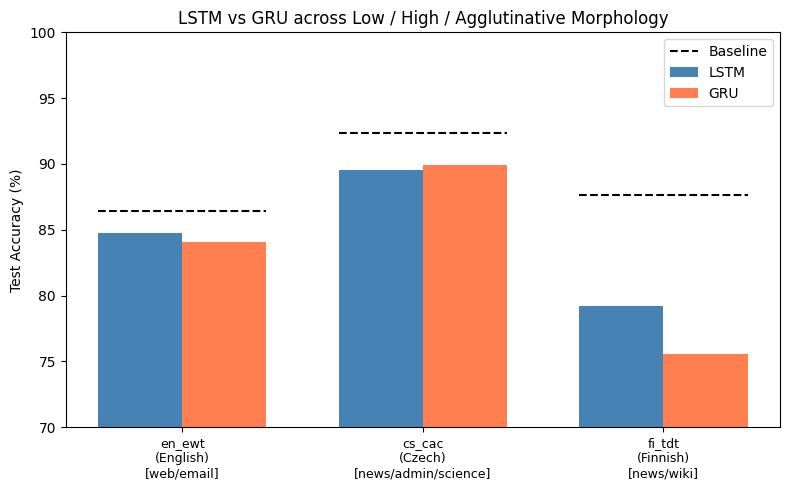

In [ ]:
# Three languages chosen to represent low, medium, and high morphological complexity
# — giving the LSTM vs GRU comparison a meaningful linguistic dimension
primary = ['en_ewt', # English (low morphology, reference point)
           'cs_cac', # Czech (high morphology)
           'fi_tdt'] # Finnish (agglutinative)

results_rnn = {name: {} for name in primary}

for name in primary:
    d = all_data[name]
    print(f"\n{'='*55}")
    print(f"{name}  ({d['language']} / {d['genre']})")
    print(f"{'='*55}")
    print("Baseline:")
    majority_tag_baseline(d['X_train'], d['y_train'], d['X_test'], d['y_test'])

    for rnn_type in ('lstm', 'gru'):
        print(f"\nTraining {rnn_type.upper()}...")
        tagger = RNNPoSTagger(embedding_dim=64, hidden_dim=128, rnn_type=rnn_type,
                              bidirectional=False, dropout=0.3, n_epochs=10)
        tagger.fit(d['X_train'], d['y_train'])
        acc = tagger.score(d['X_test'], d['y_test'])
        results_rnn[name][rnn_type] = acc
        print(f"  {rnn_type.upper()} test accuracy: {100*acc:.2f}%")

# Plot
x = np.arange(len(primary))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, [results_rnn[n]['lstm']*100 for n in primary],
       width, label='LSTM', color='steelblue')
ax.bar(x + width/2, [results_rnn[n]['gru'] *100 for n in primary],
       width, label='GRU',  color='coral')

# Add baseline markers so you can see how much each model beats it
for i, name in enumerate(primary):
    _, base = majority_tag_baseline(
        all_data[name]['X_train'], all_data[name]['y_train'],
        all_data[name]['X_test'],  all_data[name]['y_test'], verbose=False
        )
    ax.hlines(base*100, i - width, i + width,
              colors='black', linestyles='dashed', linewidth=1.5,
              label='Baseline' if i == 0 else '')

ax.set_xticks(x)
ax.set_xticklabels([
    f"{n}\n({all_data[n]['language']})\n[{all_data[n]['genre']}]"
    for n in primary], fontsize=9)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('LSTM vs GRU across Low / High / Agglutinative Morphology')
ax.set_ylim(70, 100)
ax.legend()
plt.tight_layout()
plt.show()

# 2) Bidirectionality

In [11]:
results_bidir = {name: {} for name in primary}

for name in primary:
    d = all_data[name]
    print(f"\n{name} ({all_data[name]['language']})")
    for bidir in (False, True):
        label = 'Bidirectional' if bidir else 'Unidirectional'
        tagger = RNNPoSTagger(embedding_dim=64, hidden_dim=128, rnn_type='lstm',
                              bidirectional=bidir, dropout=0.3, n_epochs=10)
        tagger.fit(d['X_train'], d['y_train'])
        acc = tagger.score(d['X_test'], d['y_test'])
        key = 'bidir' if bidir else 'unidir'
        results_bidir[name][key] = acc
        print(f"  {label}: {100*acc:.2f}%")


en_ewt (English)


  Epoch 1: loss=1.7500, acc=47.15%


  Epoch 2: loss=1.0751, acc=65.92%


  Epoch 3: loss=0.8802, acc=71.79%


  Epoch 4: loss=0.7638, acc=75.25%


...

  Epoch 6: loss=0.8460, acc=71.36%


  Epoch 7: loss=0.7814, acc=73.54%


  Epoch 8: loss=0.7234, acc=75.56%


  Epoch 9: loss=0.6734, acc=77.26%


  Epoch 10: loss=0.6259, acc=78.98%
  Bidirectional: 77.68%


# 3) Droupout regularisation
shows train vs. test gap at different dropout rates


dropout=0.0


  Epoch 1: loss=0.7256, acc=77.17%


  Epoch 2: loss=0.2695, acc=91.25%


  Epoch 3: loss=0.1503, acc=95.03%


  Epoch 4: loss=0.0958, acc=96.78%


...

  Epoch 6: loss=0.3235, acc=89.67%


  Epoch 7: loss=0.2923, acc=90.63%


  Epoch 8: loss=0.2699, acc=91.40%


  Epoch 9: loss=0.2513, acc=91.94%


  Epoch 10: loss=0.2377, acc=92.41%
  Train: 95.19%  |  Test: 88.46%


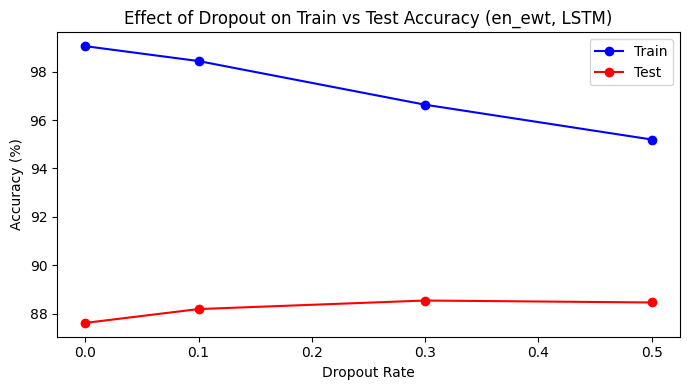

In [ ]:
dropout_rates = [0.0, 0.1, 0.3, 0.5]
d = all_data['en_ewt']
drop_results  = {}

for dr in dropout_rates:
    print(f"\ndropout={dr}")
    tagger = RNNPoSTagger(embedding_dim=64, hidden_dim=128, rnn_type='lstm',
                          bidirectional=False, dropout=dr, n_epochs=10, lr=0.01)
    tagger.fit(d['X_train'], d['y_train'])
    train_acc = tagger.score(d['X_train'], d['y_train'])
    test_acc  = tagger.score(d['X_test'],  d['y_test'])
    drop_results[dr] = {'train': train_acc, 'test': test_acc}
    print(f"  Train: {100*train_acc:.2f}%  |  Test: {100*test_acc:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
drs = list(drop_results)
ax.plot(drs, [drop_results[r]['train']*100 for r in drs], 'b-o', label='Train')
ax.plot(drs, [drop_results[r]['test'] *100 for r in drs], 'r-o', label='Test')
ax.set_xlabel('Dropout Rate')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Effect of Dropout on Train vs Test Accuracy (en_ewt, LSTM)')
ax.legend()
plt.tight_layout()
plt.show()

# 4) Data Augmentation - English


augment_p=0.0


  Epoch 1: loss=1.7590, acc=47.49%


  Epoch 2: loss=1.0629, acc=66.41%


  Epoch 3: loss=0.8688, acc=72.05%


  Epoch 4: loss=0.7573, acc=75.37%


...

  Epoch 6: loss=1.1827, acc=61.34%


  Epoch 7: loss=1.1378, acc=62.69%


  Epoch 8: loss=1.1011, acc=63.95%


  Epoch 9: loss=1.0715, acc=64.97%


  Epoch 10: loss=1.0445, acc=65.82%
  Test accuracy: 82.15%


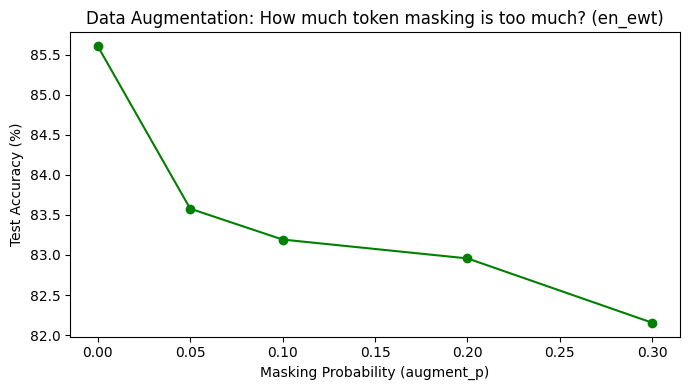

In [ ]:
# How much token masking is too much?
augment_probs = [0.0, 0.05, 0.10, 0.20, 0.30]
d = all_data['en_ewt']
aug_results = {}

for ap in augment_probs:
    print(f"\naugment_p={ap}")
    tagger = RNNPoSTagger(embedding_dim=64, hidden_dim=128, rnn_type='lstm',
                          bidirectional=False, dropout=0.3, n_epochs=10,
                          augment_p=ap)
    tagger.fit(d['X_train'], d['y_train'])
    acc = tagger.score(d['X_test'], d['y_test'])
    aug_results[ap] = acc
    print(f"  Test accuracy: {100*acc:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(aug_results), [v*100 for v in aug_results.values()], 'g-o')
ax.set_xlabel('Masking Probability (augment_p)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Data Augmentation: How much token masking is too much? (en_ewt)')
plt.tight_layout()
plt.show()

# 4) Data augmentation - Finnish


augment_p=0.0


  Epoch 1: loss=1.7971, acc=43.63%


  Epoch 2: loss=1.3789, acc=54.48%


  Epoch 3: loss=1.2194, acc=59.30%


  Epoch 4: loss=1.1064, acc=62.78%


...

  Epoch 6: loss=1.3652, acc=53.88%


  Epoch 7: loss=1.3177, acc=55.52%


  Epoch 8: loss=1.2742, acc=57.01%


  Epoch 9: loss=1.2348, acc=58.21%


  Epoch 10: loss=1.1999, acc=59.65%
  Test accuracy: 75.08%


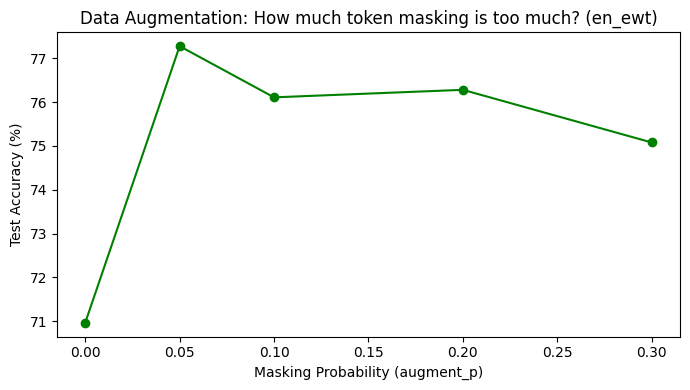

In [ ]:
# How much token masking is too much?
augment_probs = [0.0, 0.05, 0.10, 0.20, 0.30]
d = all_data['fi_tdt']
aug_results = {}

for ap in augment_probs:
    print(f"\naugment_p={ap}")
    tagger = RNNPoSTagger(embedding_dim=64, hidden_dim=128, rnn_type='lstm',
                          bidirectional=False, dropout=0.3, n_epochs=10,
                          augment_p=ap)
    tagger.fit(d['X_train'], d['y_train'])
    acc = tagger.score(d['X_test'], d['y_test'])
    aug_results[ap] = acc
    print(f"  Test accuracy: {100*acc:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(aug_results), [v*100 for v in aug_results.values()], 'g-o')
ax.set_xlabel('Masking Probability (augment_p)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Data Augmentation: How much token masking is too much? (en_ewt)')
plt.tight_layout()
plt.show()

# 5) Model Complexity

  Epoch 1: loss=2.4390, acc=23.88%


  Epoch 2: loss=1.8695, acc=43.35%


  Epoch 3: loss=1.5664, acc=52.45%


  Epoch 4: loss=1.3846, acc=57.50%


  Epoch 5: loss=1.2665, acc=60.80%
  embed= 16, hidden= 32: 315,633 params → 64.68%


...

  Epoch 1: loss=1.3731, acc=58.72%


  Epoch 2: loss=0.8016, acc=73.95%


  Epoch 3: loss=0.6408, acc=79.03%


  Epoch 4: loss=0.5428, acc=82.21%


  Epoch 5: loss=0.4743, acc=84.44%
  embed=128, hidden=256: 2,869,009 params → 83.94%


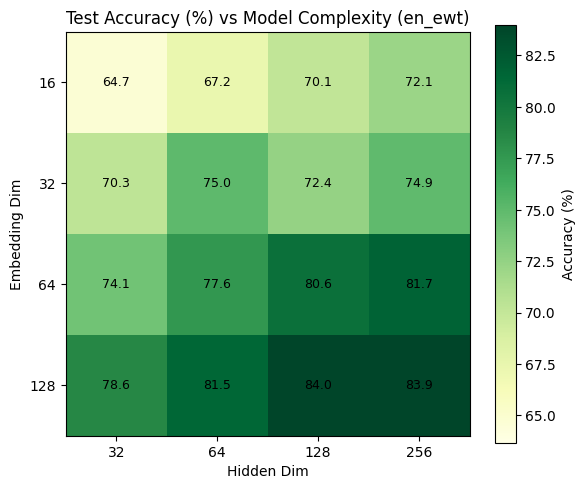

In [14]:
# Explore embedding_dim × hidden_dim trade-off
embed_dims  = [16, 32, 64, 128]
hidden_dims = [32, 64, 128, 256]
d = all_data['en_ewt']
complexity  = []

for emb in embed_dims:
    for hid in hidden_dims:
        tagger = RNNPoSTagger(embedding_dim=emb, hidden_dim=hid, rnn_type='lstm',
                              bidirectional=False, dropout=0.3, n_epochs=5)
        tagger.fit(d['X_train'], d['y_train'])
        acc    = tagger.score(d['X_test'], d['y_test'])
        n_params = sum(p.numel() for p in tagger.model_.parameters())
        complexity.append(dict(embed=emb, hidden=hid, params=n_params, acc=acc))
        print(f"  embed={emb:3d}, hidden={hid:3d}: {n_params:>7,} params → {100*acc:.2f}%")

# Heatmap
acc_grid = np.array([r['acc'] for r in complexity]).reshape(
               len(embed_dims), len(hidden_dims)) * 100

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(acc_grid, cmap='YlGn', vmin=acc_grid.min()-1, vmax=acc_grid.max())
ax.set_xticks(range(len(hidden_dims))); ax.set_xticklabels(hidden_dims)
ax.set_yticks(range(len(embed_dims)));  ax.set_yticklabels(embed_dims)
ax.set_xlabel('Hidden Dim'); ax.set_ylabel('Embedding Dim')
ax.set_title('Test Accuracy (%) vs Model Complexity (en_ewt)')
for i in range(len(embed_dims)):
    for j in range(len(hidden_dims)):
        ax.text(j, i, f"{acc_grid[i,j]:.1f}", ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Accuracy (%)')
plt.tight_layout()
plt.show()

# 6) Universal vs. Language-specific Tags

In [15]:
for source_name in ['en_ewt', 'cs_cac']:
    d = all_data[source_name]
    print(f"\n{'='*50}")
    print(f"{source_name} ({d['language']})")
    print(f"{'='*50}")

    for use_upos in (True, False):
        tagset_name = 'UPOS (universal)' if use_upos else 'XPOS (language-specific)'
        X_tr, y_tr = load_ud_split(d['train_path'], use_upos=use_upos)
        X_te, y_te = load_ud_split(d['test_path'],  use_upos=use_upos)

        unique_tags = len({t for tags in y_tr for t in tags})
        print(f"\n  {tagset_name}: {unique_tags} unique tags")

        tagger = RNNPoSTagger(embedding_dim=64, hidden_dim=128, rnn_type='lstm',
                              bidirectional=True, dropout=0.3,
                              n_epochs=15, lr=0.01)
        tagger.fit(X_tr, y_tr)
        acc = tagger.score(X_te, y_te)
        print(f"  Test accuracy: {100*acc:.2f}%")


en_ewt (English)

  UPOS (universal): 17 unique tags


  Epoch 1: loss=0.7925, acc=74.80%


  Epoch 2: loss=0.3761, acc=87.98%


  Epoch 3: loss=0.2595, acc=91.84%


  Epoch 4: loss=0.1972, acc=93.86%


...

  Epoch 11: loss=0.2392, acc=92.87%


  Epoch 12: loss=0.2273, acc=93.31%


  Epoch 13: loss=0.2298, acc=93.17%


  Epoch 14: loss=0.2062, acc=93.79%


  Epoch 15: loss=0.1935, acc=94.18%
  Test accuracy: 82.12%


# 7) Full Cross-Language Comparison
11 sources, uses best configuration: BiLSTM, dropout=0.3


en_ewt (English / web/email)
  Most frequent tag:           'NOUN'
  Global majority accuracy:     16.40%
  Per-token majority accuracy:  86.40%


  Epoch 1: loss=0.8834, acc=72.32%


  Epoch 2: loss=0.4687, acc=85.01%


  Epoch 3: loss=0.3553, acc=88.78%


  Epoch 4: loss=0.2898, acc=90.92%


...

  Epoch 16: loss=0.1149, acc=96.31%


  Epoch 17: loss=0.1148, acc=96.31%


  Epoch 18: loss=0.1127, acc=96.40%


  Epoch 19: loss=0.1108, acc=96.48%


  Epoch 20: loss=0.1092, acc=96.49%
  Baseline: 90.7%  |  BiLSTM: 93.8%


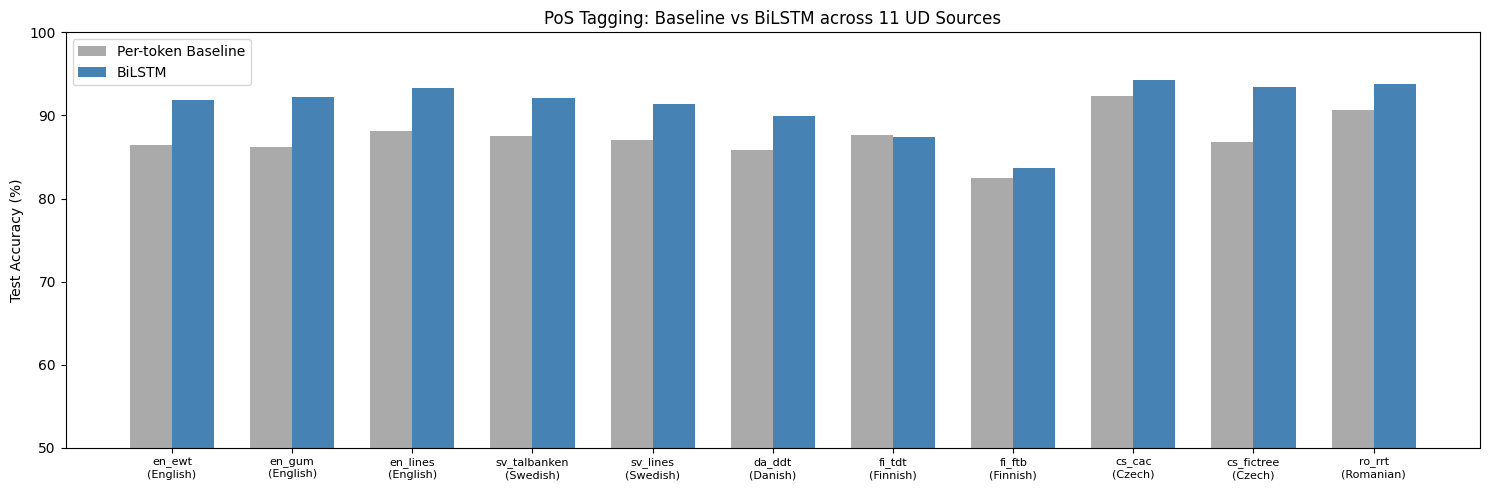

In [ ]:
# Best configuration from experiments above
best_kwargs = dict(embedding_dim=64, hidden_dim=128, rnn_type='lstm',
                   bidirectional=True, dropout=0.3, n_epochs=20, lr=0.01,
                   augment_p=0.05)

final_results = {}

for name, d in all_data.items():
    print(f"\n{name} ({d['language']} / {d['genre']})")
    _, base_acc = majority_tag_baseline(
        d['X_train'], d['y_train'], d['X_test'], d['y_test'])

    tagger = RNNPoSTagger(**best_kwargs)
    tagger.fit(d['X_train'], d['y_train'])
    model_acc = tagger.score(d['X_test'], d['y_test'])

    final_results[name] = dict(
        language=d['language'], genre=d['genre'],
        baseline=base_acc, model=model_acc
    )
    print(f"  Baseline: {100*base_acc:.1f}%  |  BiLSTM: {100*model_acc:.1f}%")

# Summary bar chart
names   = list(final_results)
base_v  = [final_results[n]['baseline']*100 for n in names]
model_v = [final_results[n]['model']   *100 for n in names]
labels  = [f"{n}\n({final_results[n]['language']})" for n in names]

x, w = np.arange(len(names)), 0.35
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - w/2, base_v,  w, label='Per-token Baseline', color='#aaa')
ax.bar(x + w/2, model_v, w, label='BiLSTM',             color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('PoS Tagging: Baseline vs BiLSTM across 11 UD Sources')
ax.set_ylim(50, 100)
ax.legend()
plt.tight_layout()
plt.show()

## Reflections

### What was hard
Refactoring the original flat code into a proper sklearn-style class was tricky. Figuring out where to store the vocabulary and how to share it correctly between fit() and predict() took a while, especially making sure OOV words were handled properly at test time. pack_padded_sequence and pad_packed_sequence were also confusing and I could not understand why they were needed. It took me a long time to find out that forgetting the total_length argument (which specifies how long the output tensor should be) causes shape mismatches.

### What was educational
Seeing how strong the per-token majority baseline already is (86-92% on most languages) was surprising. It makes clear that most of POS tagging is lexical lookup, and the neural model's real value is in resolving the genuinely ambiguous cases. The data augmentation experiment was also educational in an unexpected way: the opposite results for English and Finnish (I did Finnish as an additional test after the English results came in) showed that the same technique can help or hurt depending on the language's OOV rate, which is a good lesson about the importance of testing assumptions rather than applying techniques blindly.

### What took most time
Getting the code right and being confident it was actually doing what it was supposed to do. Building the final version of the pipeline took many iterations - each experiment required going back and adjusting earlier cells, rerunning everything, and double-checking the results made sense. Running the experiments themselves was also time-consuming, especially the full cross-language comparison and the model complexity grid search, which each take 40-50 minutes on a GPU even after the code is correct.
